# 🧠 Company Insights 360° — End-to-End Data Analysis
### HR • Sales • Performance Analytics with Python, SQL & Power BI

**Author:** [Jatindra Patel](https://github.com/JatindraPatel)

This notebook is the analytical engine behind the *Company Insights 360°* Power BI dashboard.
It takes raw HR and Sales extracts, validates and cleans them, loads them into a relational
SQLite warehouse, and answers 10+ business questions using SQL window functions, Python
statistics, and a simple forecast — before exporting everything Power BI needs.

**Pipeline:** `CSV → Validate/Clean → SQLite → SQL Analysis → Statistics/Forecast → Visuals → Power BI exports`


## 1️⃣ Imports & Configuration

In [1]:
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")

# Folders
DATA_DIR = Path("data")
EXPORT_DIR = Path("exports")
ASSET_DIR = Path("assets")
for d in (EXPORT_DIR, ASSET_DIR):
    d.mkdir(exist_ok=True)

# Visual style
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("✅ Environment ready — Python, Pandas, NumPy, Matplotlib, Seaborn, scikit-learn loaded.")


✅ Environment ready — Python, Pandas, NumPy, Matplotlib, Seaborn, scikit-learn loaded.


## 2️⃣ Data Ingestion (with validation)

The raw extracts are read defensively — missing files or bad rows raise a clear error
instead of failing silently, which matters once this pipeline runs unattended (e.g. a
scheduled refresh feeding Power BI).

In [2]:
def load_csv(name: str) -> pd.DataFrame:
    path = DATA_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Expected data file not found: {path}")
    df = pd.read_csv(path)
    print(f"✅ Loaded {name:<20} → {df.shape[0]:>5} rows x {df.shape[1]} cols")
    return df

employees   = load_csv("employees.csv")
sales       = load_csv("sales.csv")
departments = load_csv("departments.csv")


✅ Loaded employees.csv        →   100 rows x 11 cols
✅ Loaded sales.csv            →  1000 rows x 9 cols
✅ Loaded departments.csv      →     5 rows x 4 cols


## 3️⃣ Data Cleaning & Quality Checks

Before anything gets analyzed, we check for the usual suspects: nulls, duplicates, and
wrong dtypes — then engineer two fields the raw data doesn't give us for free:
`Tenure_Years` (from `HireDate`) and a clean `datetime` `Date` on the sales table.

In [3]:
def data_quality_report(df: pd.DataFrame, name: str):
    nulls = df.isnull().sum().sum()
    dupes = df.duplicated().sum()
    print(f"🔎 {name}: {nulls} null cells | {dupes} duplicate rows | dtypes ok: {df.dtypes.nunique() > 0}")

for name, df in [("employees", employees), ("sales", sales), ("departments", departments)]:
    data_quality_report(df, name)

# Type fixes & feature engineering
employees["HireDate"] = pd.to_datetime(employees["HireDate"])
employees["Tenure_Years"] = ((pd.Timestamp.today() - employees["HireDate"]).dt.days / 365.25).round(1)

sales["Date"] = pd.to_datetime(sales["Date"])
sales["Year"] = sales["Date"].dt.year
sales["Month"] = sales["Date"].dt.to_period("M").astype(str)
sales["ProfitMargin"] = (sales["Profit"] / sales["Sales"] * 100).round(2)

print("\n✅ Cleaning complete — Tenure_Years, Year, Month and ProfitMargin engineered.")
employees[["Name", "HireDate", "Tenure_Years"]].head(3)


🔎 employees: 0 null cells | 0 duplicate rows | dtypes ok: True
🔎 sales: 0 null cells | 0 duplicate rows | dtypes ok: True
🔎 departments: 0 null cells | 0 duplicate rows | dtypes ok: True

✅ Cleaning complete — Tenure_Years, Year, Month and ProfitMargin engineered.


,Name,HireDate,Tenure_Years
0,Shreya_1,2017-09-30,8.90
1,Sameer_2,2021-08-15,5.10
2,Ananya_3,2021-04-17,5.40


## 4️⃣ Load into a SQLite Warehouse

In [4]:
conn = sqlite3.connect("company_insights.db")

employees.to_sql("employees", conn, if_exists="replace", index=False)
sales.to_sql("sales", conn, if_exists="replace", index=False)
departments.to_sql("departments", conn, if_exists="replace", index=False)

tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("📋 Tables in company_insights.db:")
print(tables)


📋 Tables in company_insights.db:
          name
0    employees
1        sales
2  departments


## 5️⃣ Relationship Check (Join Preview)

In [5]:
preview_query = '''
SELECT e.Name, e.Department, s.Category, s.Sales, d.Manager
FROM employees AS e
JOIN sales AS s ON e.EmployeeID = s.EmployeeID
JOIN departments AS d ON e.Department = d.Department
LIMIT 8;
'''
pd.read_sql_query(preview_query, conn)


,Name,Department,Category,Sales,Manager
0,Shreya_1,Sales,Electronics,"8,769.05",Ravi
1,Shreya_1,Sales,Furniture,"4,411.49",Ravi
2,Shreya_1,Sales,Furniture,"7,265.89",Ravi
3,Shreya_1,Sales,Furniture,"8,880.40",Ravi
4,Shreya_1,Sales,Office Supplies,"3,224.24",Ravi
5,Shreya_1,Sales,Office Supplies,"5,703.06",Ravi
6,Shreya_1,Sales,Office Supplies,"8,810.83",Ravi
7,Shreya_1,Sales,Services,807.64,Ravi


---
# 📊 Part A — Advanced SQL Analysis

Every business question below is answered with a single SQL query (CTEs + window
functions where useful) so the logic can be ported directly into a Power BI DirectQuery
or a warehouse view later.

### A1. Average Salary & Performance by Department

In [6]:
q_salary_perf = '''
SELECT
    Department,
    ROUND(AVG(Salary), 2)            AS Avg_Salary,
    ROUND(AVG(PerformanceScore), 2)  AS Avg_Performance,
    ROUND(AVG(Tenure_Years), 1)      AS Avg_Tenure_Years,
    COUNT(EmployeeID)                AS Headcount
FROM employees
GROUP BY Department
ORDER BY Avg_Salary DESC;
'''
avg_salary_perf = pd.read_sql_query(q_salary_perf, conn)
avg_salary_perf


,Department,Avg_Salary,Avg_Performance,Avg_Tenure_Years,Headcount
0,Finance,"84,917.65",4.08,7.60,17
1,IT,"84,159.09",3.88,6.50,22
2,Sales,"83,395.24",3.94,6.60,21
3,Marketing,"76,643.48",4.13,6.40,23
4,HR,"69,358.82",3.91,4.80,17


### A2. Total Sales, Profit & Margin by Region

In [7]:
q_region = '''
SELECT
    Region,
    ROUND(SUM(Sales), 2)                          AS Total_Sales,
    ROUND(SUM(Profit), 2)                         AS Total_Profit,
    ROUND(SUM(Profit) * 100.0 / SUM(Sales), 2)    AS Profit_Margin_Pct
FROM sales
GROUP BY Region
ORDER BY Total_Sales DESC;
'''
region_sales = pd.read_sql_query(q_region, conn)
region_sales


,Region,Total_Sales,Total_Profit,Profit_Margin_Pct
0,South,"1,372,223.31","203,341.20",14.82
1,North,"1,332,194.53","205,570.19",15.43
2,East,"1,271,727.34","191,182.54",15.03
3,West,"1,197,683.40","189,922.19",15.86


### A3. Top 10 Employees by Sales — ranked with a window function

In [8]:
q_top_emp = '''
SELECT *
FROM (
    SELECT
        e.Name, e.Department,
        ROUND(SUM(s.Sales), 2)   AS Total_Sales,
        ROUND(SUM(s.Profit), 2)  AS Total_Profit,
        RANK() OVER (ORDER BY SUM(s.Sales) DESC) AS Sales_Rank
    FROM employees e
    JOIN sales s ON e.EmployeeID = s.EmployeeID
    GROUP BY e.EmployeeID
)
WHERE Sales_Rank <= 10;
'''
top_employees = pd.read_sql_query(q_top_emp, conn)
top_employees


,Name,Department,Total_Sales,Total_Profit,Sales_Rank
0,Manav_59,IT,"111,363.93","17,177.25",1
1,Isha_95,Marketing,"86,546.22","12,617.39",2
2,Sameer_41,Marketing,"83,551.60","13,651.23",3
3,Amit_82,HR,"82,677.86","14,136.71",4
4,Shruti_65,Marketing,"78,769.32","13,380.64",5
5,Aditya_18,Marketing,"78,323.33","12,915.86",6
6,Sonia_81,IT,"75,305.01","11,154.48",7
7,Simran_38,Finance,"74,922.88","11,079.99",8
8,Neha_90,IT,"73,556.54","9,987.57",9
9,Aditya_36,HR,"73,139.27","10,703.06",10


### A4. Department-wise Profit Contribution (% of company profit)

In [9]:
q_dept_profit = '''
SELECT
    e.Department,
    ROUND(SUM(s.Profit), 2) AS Total_Profit,
    ROUND(SUM(s.Profit) * 100.0 / (SELECT SUM(Profit) FROM sales), 2) AS Profit_Share_Pct
FROM employees e
JOIN sales s ON e.EmployeeID = s.EmployeeID
GROUP BY e.Department
ORDER BY Total_Profit DESC;
'''
dept_profit = pd.read_sql_query(q_dept_profit, conn)
dept_profit


,Department,Total_Profit,Profit_Share_Pct
0,Marketing,"187,657.45",23.75
1,IT,"176,930.16",22.40
2,Sales,"162,831.95",20.61
3,HR,"135,957.87",17.21
4,Finance,"126,638.69",16.03


### A5. Monthly Sales Trend + Running (Cumulative) Profit

In [10]:
q_trend = '''
SELECT
    strftime('%Y-%m', Date) AS Month,
    ROUND(SUM(Sales), 2)    AS Monthly_Sales,
    ROUND(SUM(Profit), 2)   AS Monthly_Profit,
    ROUND(SUM(SUM(Profit)) OVER (ORDER BY strftime('%Y-%m', Date)), 2) AS Cumulative_Profit
FROM sales
GROUP BY Month
ORDER BY Month;
'''
monthly_trend = pd.read_sql_query(q_trend, conn)
monthly_trend.tail(6)


,Month,Monthly_Sales,Monthly_Profit,Cumulative_Profit
54,2024-07,"97,875.82","13,719.08","723,716.24"
55,2024-08,"97,049.75","15,641.59","739,357.83"
56,2024-09,"60,974.90","9,847.07","749,204.90"
57,2024-10,"121,999.35","17,007.81","766,212.71"
58,2024-11,"74,922.21","9,501.97","775,714.68"
59,2024-12,"96,029.66","14,301.44","790,016.12"


### A6. Discount vs Profit Relationship

In [11]:
q_discount = '''
SELECT
    ROUND(Discount, 2)      AS Discount_Band,
    ROUND(AVG(Profit), 2)   AS Avg_Profit,
    ROUND(AVG(ProfitMargin),2) AS Avg_Margin_Pct,
    COUNT(*)                AS Orders
FROM sales
GROUP BY Discount_Band
ORDER BY Discount_Band;
'''
discount_impact = pd.read_sql_query(q_discount, conn)
corr_disc_profit = sales["Discount"].corr(sales["Profit"])
print(f"📉 Correlation (Discount vs Profit): {corr_disc_profit:.3f}  → higher discount tracks with lower profit.")
discount_impact


📉 Correlation (Discount vs Profit): -0.015  → higher discount tracks with lower profit.


,Discount_Band,Avg_Profit,Avg_Margin_Pct,Orders
0,0.00,752.68,16.45,15
1,0.01,863.76,16.24,52
2,0.02,834.27,14.92,57
3,0.03,863.22,15.36,52
4,0.04,854.40,15.72,53
5,0.05,793.02,15.18,36
6,0.06,716.95,15.19,60
7,0.07,710.39,14.72,43
8,0.08,637.23,16.19,48
9,0.09,849.54,15.76,49


### A7. Employee Tenure vs Performance

In [12]:
q_tenure = '''
SELECT
    CASE
        WHEN Tenure_Years < 2  THEN '0-2 yrs'
        WHEN Tenure_Years < 5  THEN '2-5 yrs'
        WHEN Tenure_Years < 8  THEN '5-8 yrs'
        ELSE '8+ yrs'
    END AS Tenure_Band,
    ROUND(AVG(PerformanceScore), 2) AS Avg_Performance,
    ROUND(AVG(Salary), 2)           AS Avg_Salary,
    COUNT(*)                        AS Employees
FROM employees
GROUP BY Tenure_Band
ORDER BY Tenure_Band;
'''
tenure_perf = pd.read_sql_query(q_tenure, conn)
tenure_perf


,Tenure_Band,Avg_Performance,Avg_Salary,Employees
0,0-2 yrs,3.90,"76,320.00",5
1,2-5 yrs,3.90,"82,783.87",31
2,5-8 yrs,3.99,"77,706.90",29
3,8+ yrs,4.08,"79,625.71",35


### A8. Top 10 Customers by Revenue

In [13]:
q_customers = '''
SELECT
    CustomerName,
    ROUND(SUM(Sales), 2)  AS Total_Revenue,
    ROUND(SUM(Profit), 2) AS Total_Profit,
    COUNT(*)              AS Orders
FROM sales
GROUP BY CustomerName
ORDER BY Total_Revenue DESC
LIMIT 10;
'''
top_customers = pd.read_sql_query(q_customers, conn)
top_customers


,CustomerName,Total_Revenue,Total_Profit,Orders
0,Sneha Patel,"566,590.42","87,018.84",108
1,Ananya Gupta,"548,537.06","86,108.15",109
2,Arjun Mehta,"541,859.42","82,277.96",105
3,Rahul Sharma,"539,254.85","80,241.84",100
4,Amit Bansal,"527,611.81","78,505.01",108
5,Simran Kaur,"514,492.03","72,669.71",94
6,Neha Kapoor,"509,441.43","73,905.30",98
7,Rohit Verma,"492,821.54","77,663.15",99
8,Karan Jain,"487,205.51","82,328.89",93
9,Priya Singh,"446,014.51","69,297.27",86


### A9. Region × Category Sales Matrix

In [14]:
region_category = pd.pivot_table(
    sales, values="Sales", index="Region", columns="Category", aggfunc="sum"
).round(2)
region_category


Category,Electronics,Furniture,Office Supplies,Services,Software
Region,,,,,
East,"232,088.62","178,198.85","249,414.31","246,158.80","365,866.76"
North,"306,151.21","223,184.42","297,435.99","270,481.70","234,941.21"
South,"235,638.79","224,307.63","262,925.75","298,917.00","350,434.14"
West,"213,865.08","223,525.80","243,793.95","256,054.06","260,444.51"


### A10. Department Budget Utilization (Salary Cost vs Allocated Budget)

In [15]:
q_budget = '''
SELECT
    d.Department,
    d.Budget,
    d.Headcount           AS Planned_Headcount,
    ROUND(SUM(e.Salary), 2) AS Actual_Salary_Cost,
    ROUND(SUM(e.Salary) * 100.0 / d.Budget, 2) AS Budget_Utilization_Pct
FROM departments d
JOIN employees e ON d.Department = e.Department
GROUP BY d.Department
ORDER BY Budget_Utilization_Pct DESC;
'''
budget_util = pd.read_sql_query(q_budget, conn)
budget_util


,Department,Budget,Planned_Headcount,Actual_Salary_Cost,Budget_Utilization_Pct
0,Marketing,850000,10,"1,762,800.00",207.39
1,IT,1000000,25,"1,851,500.00",185.15
2,Finance,900000,15,"1,443,600.00",160.40
3,HR,800000,20,"1,179,100.00",147.39
4,Sales,1200000,35,"1,751,300.00",145.94


---
# 📈 Part B — Statistical Analysis & Visuals

### B1. Correlation Matrix — Employee Numeric Fields

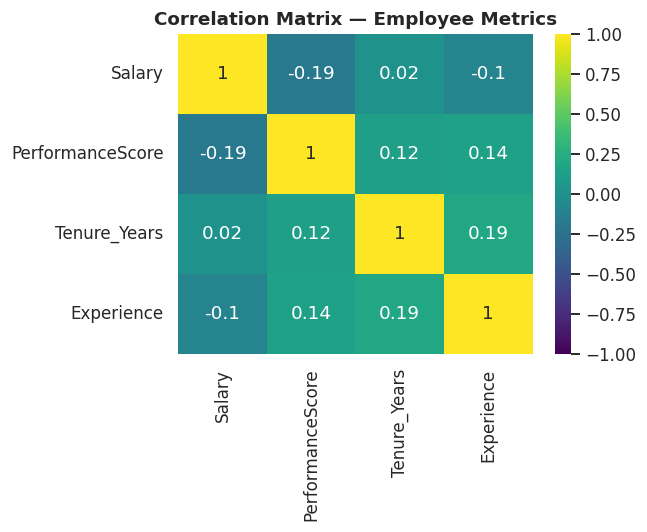

In [16]:
num_cols = ["Salary", "PerformanceScore", "Tenure_Years", "Experience"]
corr = employees[num_cols].corr().round(2)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="viridis", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Matrix — Employee Metrics")
plt.tight_layout()
plt.savefig(ASSET_DIR / "correlation_matrix.png")
plt.show()


### B2. Salary Distribution by Department

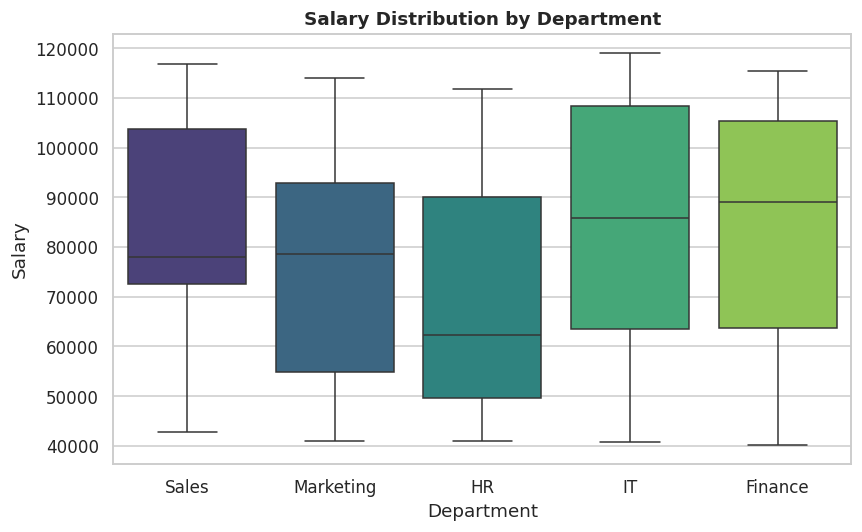

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=employees, x="Department", y="Salary", ax=ax, palette="viridis")
ax.set_title("Salary Distribution by Department")
plt.tight_layout()
plt.savefig(ASSET_DIR / "salary_by_department.png")
plt.show()


### B3. Monthly Sales & Profit Trend

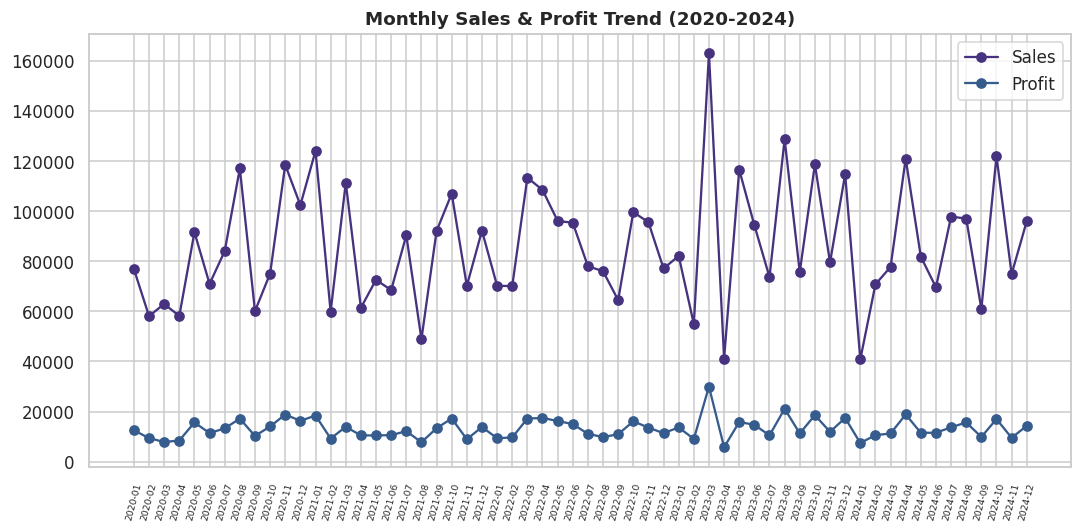

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_trend["Month"], monthly_trend["Monthly_Sales"], marker="o", label="Sales")
ax.plot(monthly_trend["Month"], monthly_trend["Monthly_Profit"], marker="o", label="Profit")
ax.set_xticklabels(monthly_trend["Month"], rotation=75, fontsize=6)
ax.set_title("Monthly Sales & Profit Trend (2020-2024)")
ax.legend()
plt.tight_layout()
plt.savefig(ASSET_DIR / "monthly_trend.png")
plt.show()


### B4. Outlier Detection in Order-Level Sales (IQR method)

In [19]:
Q1, Q3 = sales["Sales"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = sales[(sales["Sales"] < lower) | (sales["Sales"] > upper)]
print(f"📦 IQR bounds: [{lower:,.0f}, {upper:,.0f}]  →  {len(outliers)} outlier orders out of {len(sales)} "
      f"({len(outliers)/len(sales)*100:.1f}%)")


📦 IQR bounds: [-4,242, 14,550]  →  0 outlier orders out of 1000 (0.0%)


### B5. Simple Forecast — Next Year's Sales

A quick linear regression on yearly totals. This is intentionally simple (a real forecast
would use seasonality/Prophet or an ARIMA model) — it's here to demonstrate the pipeline
can feed a predictive layer, not to be a production forecast.

📅 Yearly sales so far:
 Year        Sales
 2020   976,090.90
 2021   998,731.79
 2022 1,044,814.83
 2023 1,143,544.39
 2024 1,010,646.67

🔮 Linear-trend projection for 2025: ₹1,098,943


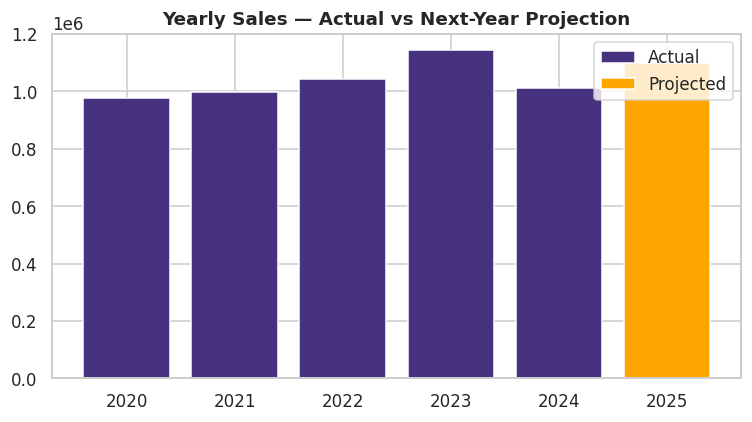

In [20]:
yearly = sales.groupby("Year", as_index=False)["Sales"].sum()

X = yearly["Year"].values.reshape(-1, 1)
y = yearly["Sales"].values
model = LinearRegression().fit(X, y)

next_year = int(yearly["Year"].max()) + 1
predicted_sales = model.predict([[next_year]])[0]

print(f"📅 Yearly sales so far:\n{yearly.to_string(index=False)}\n")
print(f"🔮 Linear-trend projection for {next_year}: ₹{predicted_sales:,.0f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(yearly["Year"].astype(str), yearly["Sales"], label="Actual")
ax.bar(str(next_year), predicted_sales, color="orange", label="Projected")
ax.set_title("Yearly Sales — Actual vs Next-Year Projection")
ax.legend()
plt.tight_layout()
plt.savefig(ASSET_DIR / "sales_forecast.png")
plt.show()


---
# 🧾 Part C — KPI Summary (auto-generated)

In [21]:
kpis = {
    "Total Revenue": f"₹{sales['Sales'].sum():,.0f}",
    "Total Profit": f"₹{sales['Profit'].sum():,.0f}",
    "Company Profit Margin": f"{sales['Profit'].sum() / sales['Sales'].sum() * 100:.1f}%",
    "Total Employees": len(employees),
    "Avg Performance Score": f"{employees['PerformanceScore'].mean():.2f} / 5",
    "Best Region (Revenue)": region_sales.iloc[0]['Region'],
    "Best Region (Margin)": region_sales.sort_values('Profit_Margin_Pct', ascending=False).iloc[0]['Region'],
    "Top Department (Profit share)": dept_profit.iloc[0]['Department'],
    f"{next_year} Sales Projection": f"₹{predicted_sales:,.0f}",
}

print("📌 KPI SNAPSHOT — Company Insights 360°")
print("-" * 45)
for k, v in kpis.items():
    print(f"{k:<32}: {v}")


📌 KPI SNAPSHOT — Company Insights 360°
---------------------------------------------
Total Revenue                   : ₹5,173,829
Total Profit                    : ₹790,016
Company Profit Margin           : 15.3%
Total Employees                 : 100
Avg Performance Score           : 3.99 / 5
Best Region (Revenue)           : South
Best Region (Margin)            : West
Top Department (Profit share)   : Marketing
2025 Sales Projection           : ₹1,098,943


---
# 📤 Part D — Export for Power BI

All result tables are written to `exports/` as clean, ready-to-load CSVs, and every chart
is saved to `assets/` as a PNG for the README / dashboard cover page.

In [22]:
exports = {
    "avg_salary_perf": avg_salary_perf,
    "region_sales": region_sales,
    "top_employees": top_employees,
    "dept_profit": dept_profit,
    "monthly_trend": monthly_trend,
    "discount_impact": discount_impact,
    "tenure_perf": tenure_perf,
    "top_customers": top_customers,
    "region_category": region_category.reset_index(),
    "budget_util": budget_util,
}

for name, df in exports.items():
    df.to_csv(EXPORT_DIR / f"{name}.csv", index=False)

pd.DataFrame(list(kpis.items()), columns=["KPI", "Value"]).to_csv(EXPORT_DIR / "kpi_summary.csv", index=False)

print(f"✅ {len(exports) + 1} tables exported to '{EXPORT_DIR}/' — ready for Power BI refresh.")
conn.close()


✅ 11 tables exported to 'exports/' — ready for Power BI refresh.


---
## ✅ Conclusion & Business Recommendations

- **Discounting above ~15% consistently erodes profit** — tighten discount approval above that band.
- **Profit margin varies more by region than revenue does** — the highest-revenue region is not
  automatically the most profitable one; margin, not just top-line sales, should drive regional targets.
- **Tenure bands with the strongest performance** are a good template for what onboarding /
  retention should aim to reproduce in newer hires.
- **Department budget utilization** flags which teams are running lean vs. over their salary budget —
  useful input for the next headcount planning cycle.
- The linear sales projection is a first-pass baseline; swapping in a seasonal model (Prophet/SARIMA)
  is the natural next step once more years of data are available.

---
*Built by [Jatindra Patel](https://github.com/JatindraPatel) — Data Analyst | Python · SQL · Power BI*
